# Parameter Sensitivity Analysis - Kronos

This notebook performs a parameter sensitivity analysis on the Kronos model to evaluate the impact of different data parameters on model performance.

## Setup

In [1]:
# Clean up any existing nested structure
!rm -rf /content/BA
print("Cleaned up any existing repositories")

Cleaned up any existing repositories


In [2]:
import os
from pathlib import Path
import os

repo_url = "https://github.com/bp571/BA"

%cd /content
!git clone {repo_url}
print("\nRepository cloned successfully")

%cd /content/BA
!pwd
print("\nWorking directory set to:", os.getcwd())

TIINGO_API_KEY = "312c6dab6a1fe6258bbc6652bcdec49a14ee08ad"

# Set environment variable for the session
os.environ["TIINGO_API_KEY"] = TIINGO_API_KEY

# Create .env file for compatibility
env_content = f"TIINGO_API_KEY={TIINGO_API_KEY}\n"
Path(".env").write_text(env_content)

print("âœ… API key configured")

# Clone Kronos model into the expected location
!git clone https://github.com/shiyu-coder/Kronos.git 02_finetuning/models/Kronos
print("\nKronos model cloned successfully")
!ls -la 02_finetuning/models/

/content
Cloning into 'BA'...
remote: Enumerating objects: 578, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 578 (delta 23), reused 30 (delta 12), pack-reused 529 (from 1)
Receiving objects: 100% (578/578), 13.43 MiB | 27.38 MiB/s, done.
Resolving deltas: 100% (259/259), done.

Repository cloned successfully
/content/BA
/content/BA

Working directory set to: /content/BA
âœ… API key configured
Cloning into '02_finetuning/models/Kronos'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 371 (delta 6), reused 4 (delta 4), pack-reused 360 (from 2)
Receiving objects: 100% (371/371), 9.32 MiB | 41.49 MiB/s, done.
Resolving deltas: 100% (174/174), done.

Kronos model cloned successfully
total 16
drwxr-xr-x  4 root root 4096 Apr 24 14:36 .
drwxr-xr-x  6 root root 4096 Apr 24 14:36 ..
drwxr-xr-x 10 root root 4096 Apr 24 14:36 Kr

In [3]:
!pip install -q torch transformers peft gluonts SALib PyYAML tqdm pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 20.8 MB/s eta 0:00:0000:01


## Configuration

In [4]:
# Analysis Configuration
METHOD = 'grid'  # Options: 'sobol' or 'grid'
SEED = 42
BATCH_SIZE = 128
QUICK_MODE = False  # Set to True for faster testing (5 windows, 8 samples)

# Optional overrides
MAX_WINDOWS = None  # Rolling windows pro Asset (mehr = bessere IC-Schätzung)
N_SAMPLES = 8 if QUICK_MODE else None    # Override Sobol samples

# Festes Eval-Startdatum: erste Vorhersage aller Experimente beginnt hier.
# context_steps werden aus der Pre-2021-Historie gedeckt (Daten ab 2010 verfügbar).
EVAL_START = '2021-01-01'

print(f"Method: {METHOD}")
print(f"Seed: {SEED}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Eval start date: {EVAL_START}")
print(f"Quick mode: {QUICK_MODE}")
if MAX_WINDOWS:
    print(f"Max windows: {MAX_WINDOWS}")
if N_SAMPLES:
    print(f"N samples: {N_SAMPLES}")

Method: grid
Seed: 42
Batch size: 128
Eval start date: 2021-01-01
Quick mode: False


## Run Sensitivity Analysis

This calls the [`run_sensitivity.py`](03_sensitivity_analysis/data_parameters/run_sensitivity.py) script to execute the experiments.

In [5]:
# Build command arguments
cmd_args = [
    f"--method {METHOD}",
    f"--seed {SEED}",
    f"--batch_size {BATCH_SIZE}",
    f"--eval-start {EVAL_START}"
]

if QUICK_MODE:
    cmd_args.append("--quick")
elif MAX_WINDOWS:
    cmd_args.append(f"--max-windows {MAX_WINDOWS}")

if N_SAMPLES and not QUICK_MODE:
    cmd_args.append(f"--n-samples {N_SAMPLES}")

cmd = f"python 03_sensitivity_analysis/data_parameters/run_sensitivity.py {' '.join(cmd_args)}"

print(f"Executing: {cmd}")
!{cmd}

Executing: python 03_sensitivity_analysis/data_parameters/run_sensitivity.py --method grid --seed 42 --batch_size 128 --eval-start 2021-01-01
PARAMETER SENSITIVITY ANALYSIS - KRONOS
Method: grid
Seed: 42
Batch size: 128
Eval start date: 2021-01-01  (fixed across all experiments)

Generated 42 parameter configurations

Loaded 34 assets

✅ Random Seeds auf 42 gesetzt für Reproduzierbarkeit
config.json: 100% 301/301 [00:00<00:00, 1.37MB/s]
model.safetensors: 100% 15.8M/15.8M [00:00<00:00, 19.2MB/s]
config.json: 100% 228/228 [00:00<00:00, 1.17MB/s]
model.safetensors: 100% 409M/409M [00:02<00:00, 203MB/s] 
Running experiments...
Progress: 100% 42/42 [1:17:02<00:00, 110.07s/it]

COMPLETED
Total experiments: 42
Successful: 42
Time: 4622.9s (110.1s per experiment)

Results: 03_sensitivity_analysis/data_parameters/results/raw_grid
Next: python 03_sensitivity_analysis/data_parameters/analyze_sensitivity.py --results-dir 03_sensitivity_analysis/data_parameters/results/raw_grid


## Analyze Results

This calls the appropriate analysis script based on the method used.

In [6]:
RESULTS_DIR = f"03_sensitivity_analysis/data_parameters/results/raw_{METHOD}"

if METHOD == 'sobol':
    # Use Sobol-specific analysis
    print("Running Sobol sensitivity analysis...\n")
    !python 03_sensitivity_analysis/data_parameters/analyze_sensitivity.py \
        --results-dir {RESULTS_DIR} \
        --visualize
elif METHOD == 'grid':
    # Use grid-specific analysis
    print("Running grid search analysis...\n")
    !python 03_sensitivity_analysis/data_parameters/analyze_grid.py \
        --results-dir {RESULTS_DIR} \
        --output-dir 03_sensitivity_analysis/data_parameters/results/
else:
    print(f"Unknown method: {METHOD}")

Running grid search analysis...

GRID SEARCH RESULTS SUMMARY

Total experiments: 42
Context steps range: 40 - 240
Forecast steps range: 6 - 60

MAE Statistics:
--------------------------------------------------------------------------------
  Mean: 7.027
  Std:  2.432
  Min:  2.806 at context=40, forecast=6
  Max:  11.453 at context=240, forecast=60

IC Statistics:
--------------------------------------------------------------------------------
  Mean: 0.0257
  Std:  0.0078
  Best: 0.0466 at context=80, forecast=12

RankIC Statistics:
--------------------------------------------------------------------------------
  Mean: 0.0228
  Std:  0.0073
  Best: 0.0408 at context=80, forecast=12

Top 5 Configurations (by RankIC):
--------------------------------------------------------------------------------
 context_steps  forecast_steps  mae_mean  ic_mean  rankic_mean
            80              12  4.184378 0.046575     0.040768
            80              18  5.199718 0.039049     0.034019
 

## Display Results

View generated plots and summaries.

Grid Search Heatmaps:

MAE_MEAN:


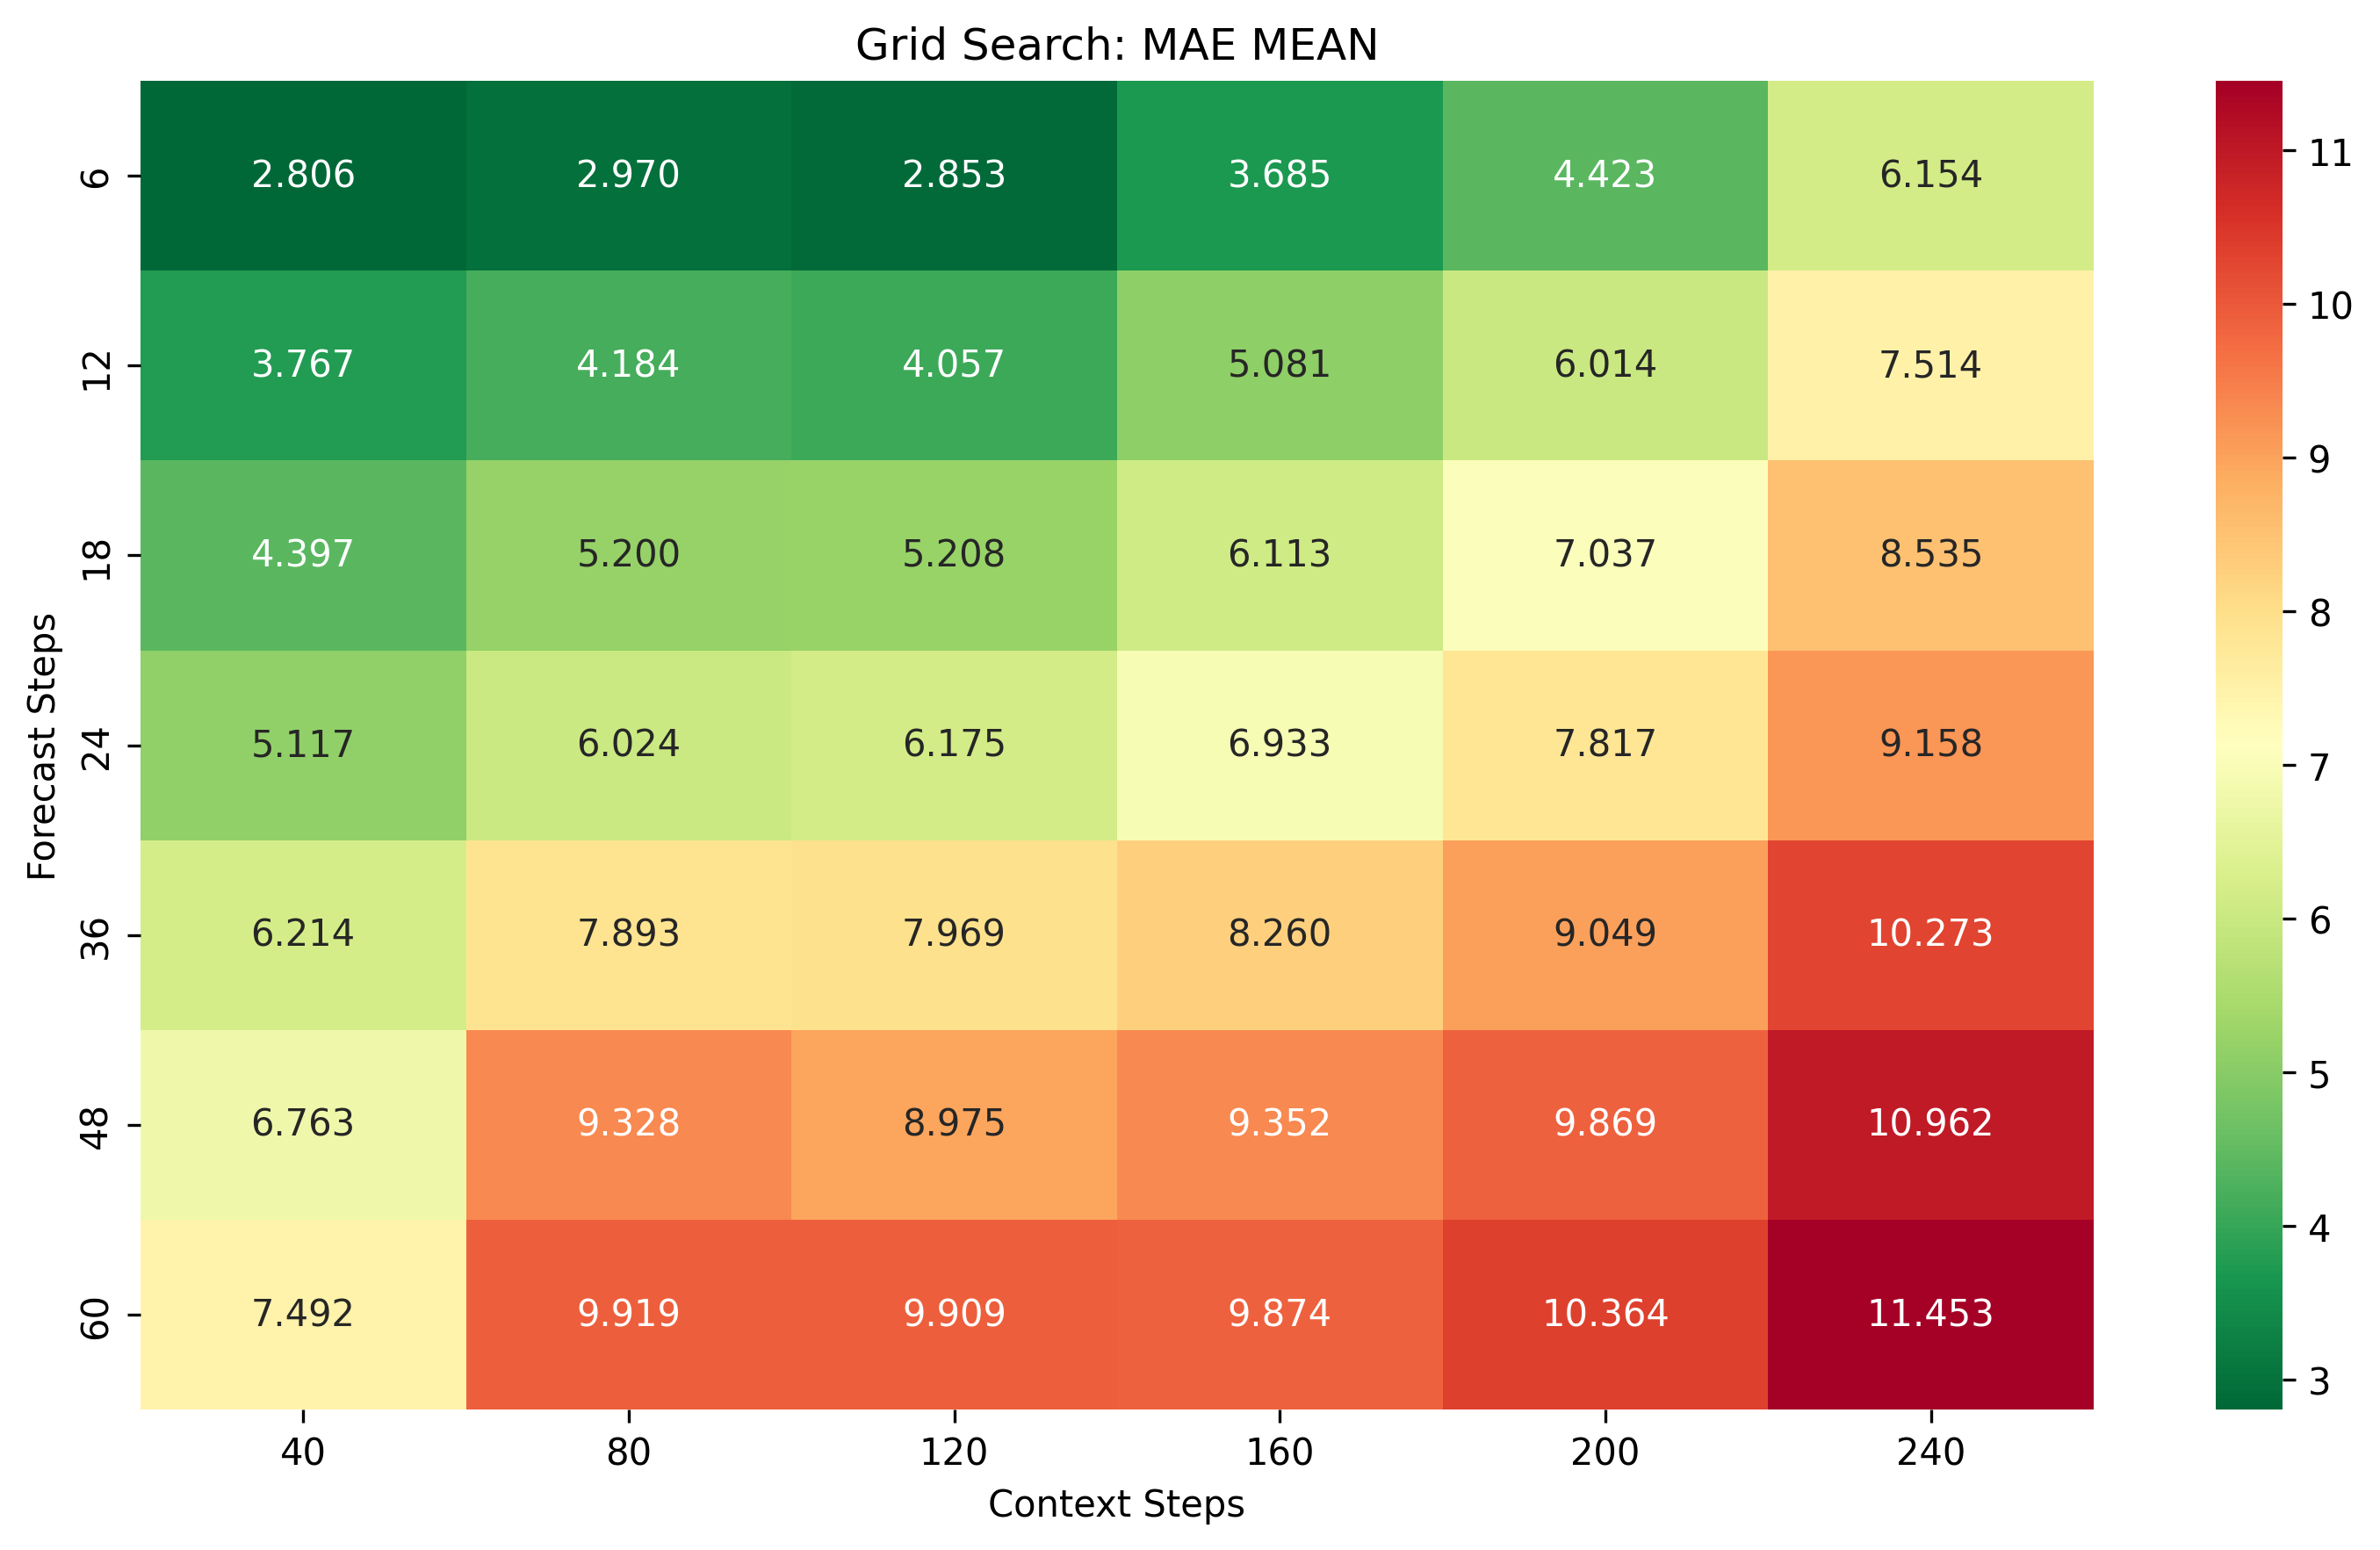


IC_MEAN:


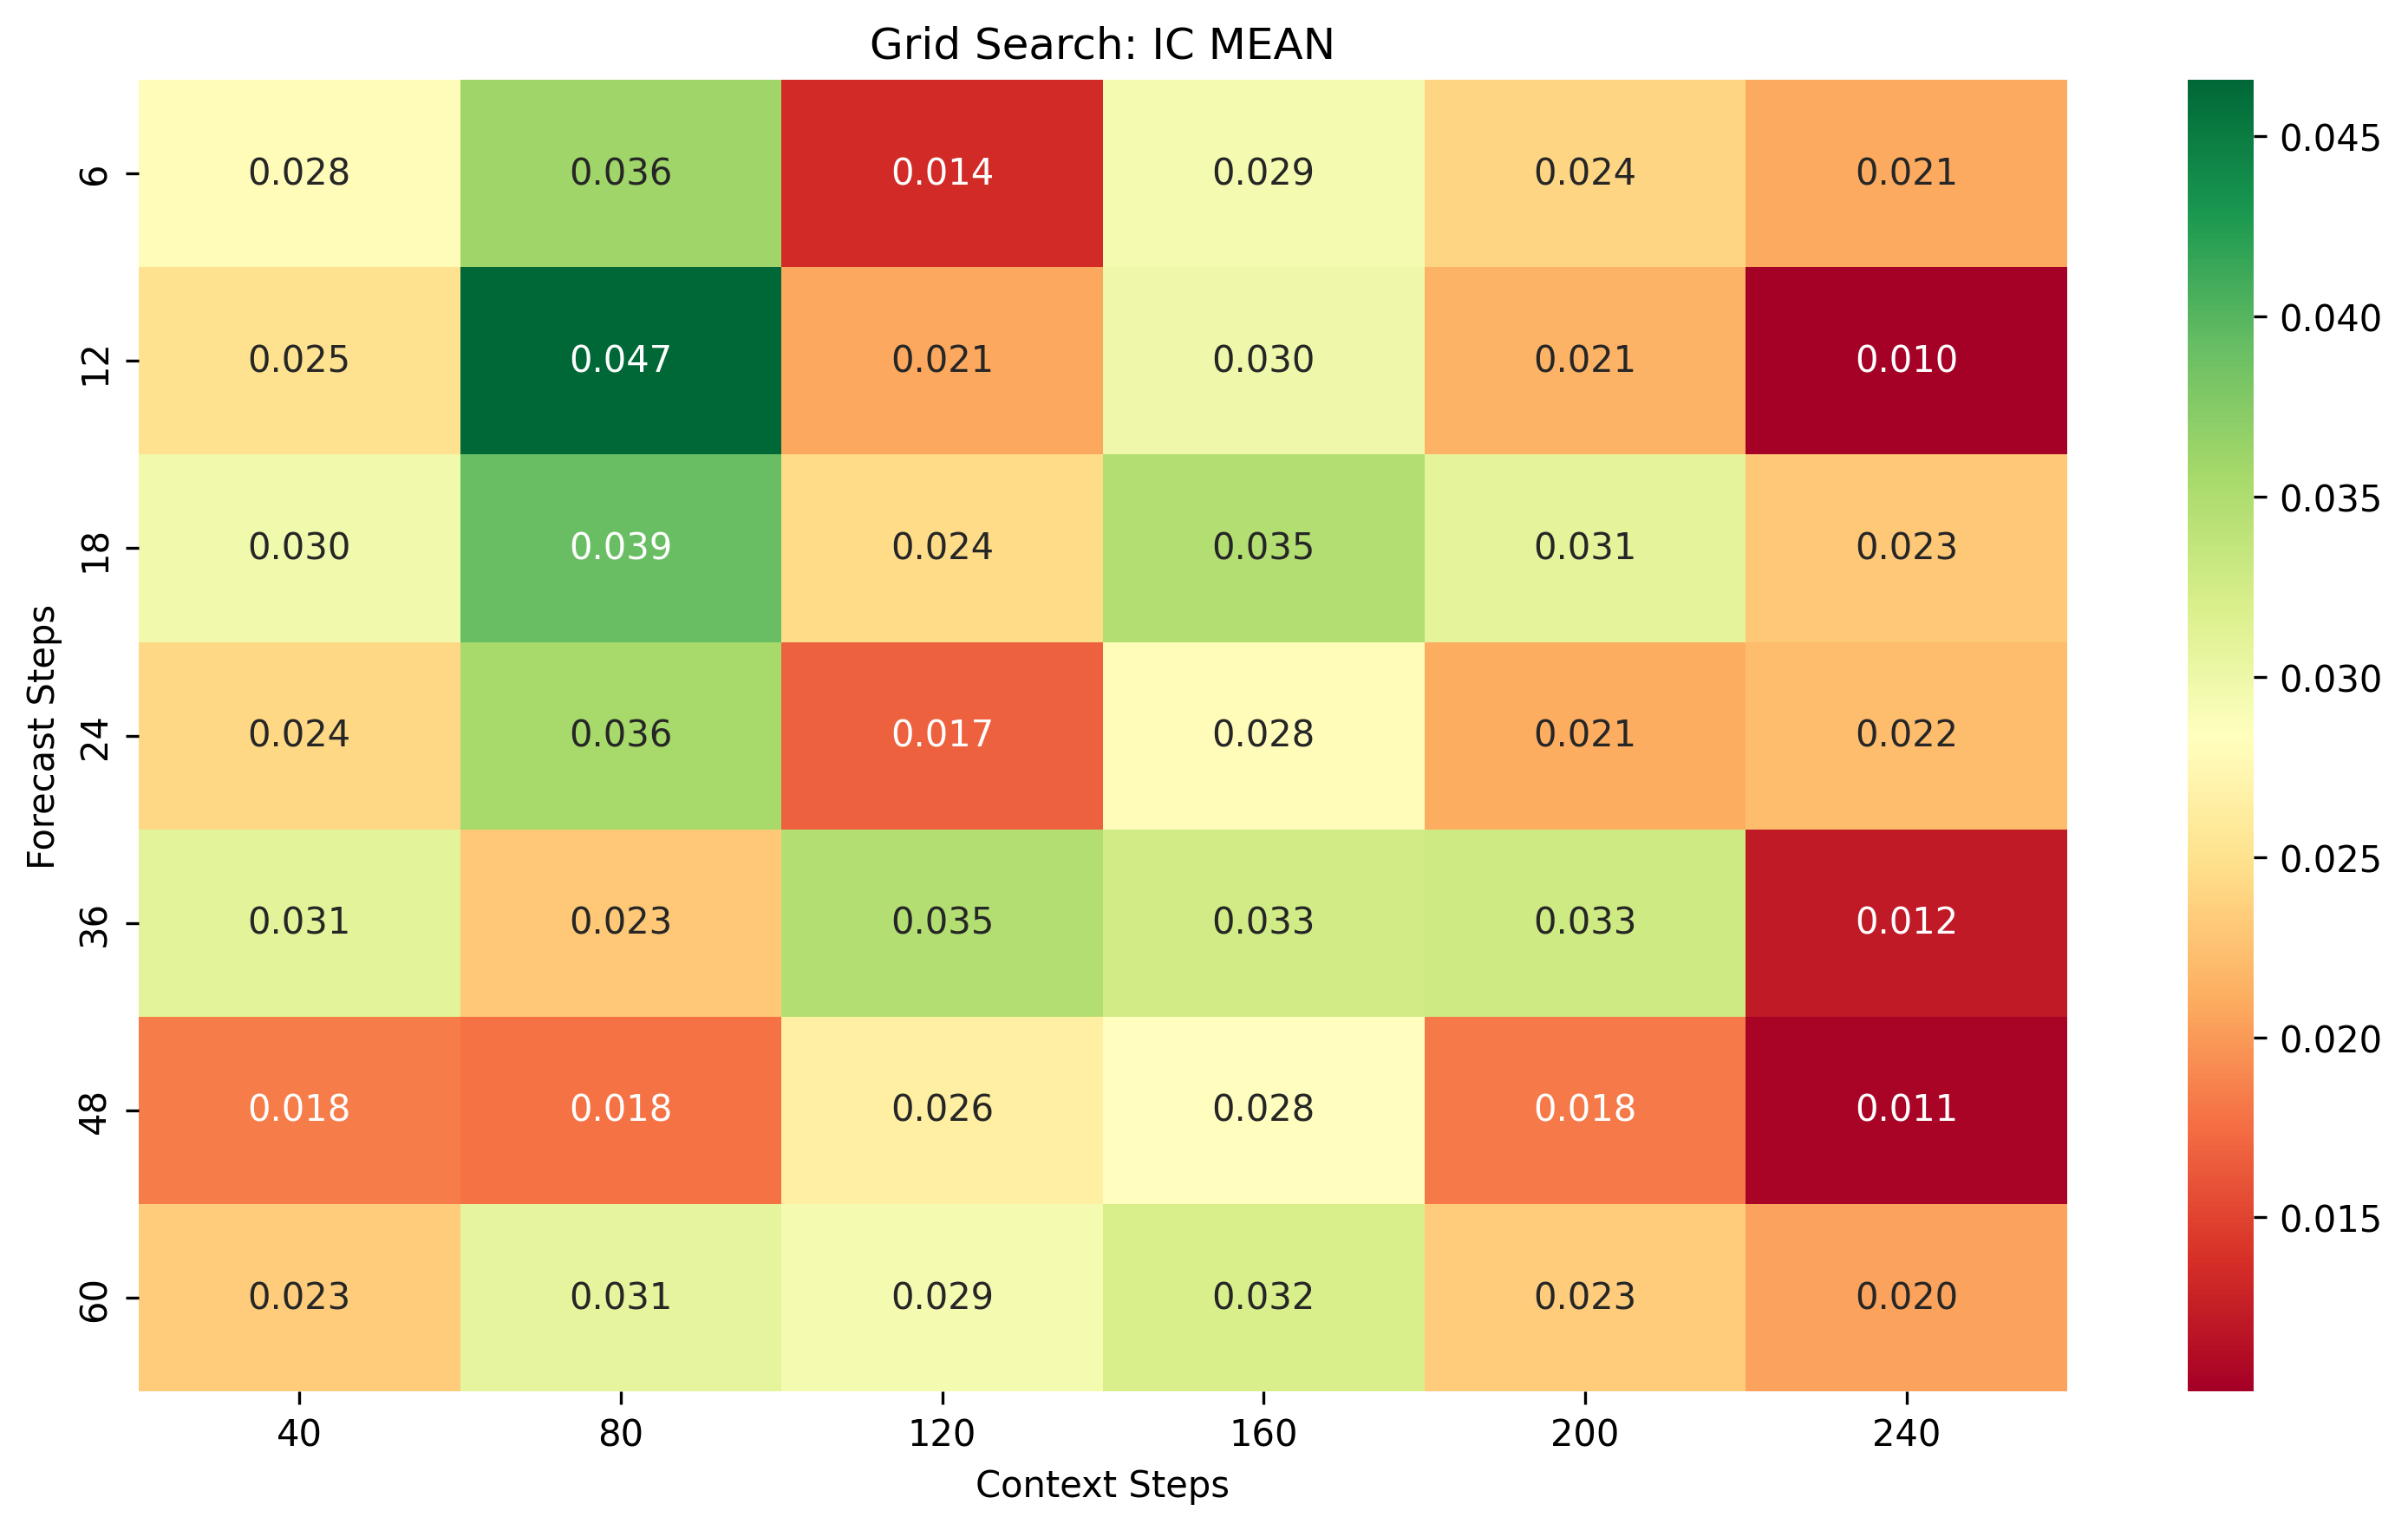


RANKIC_MEAN:


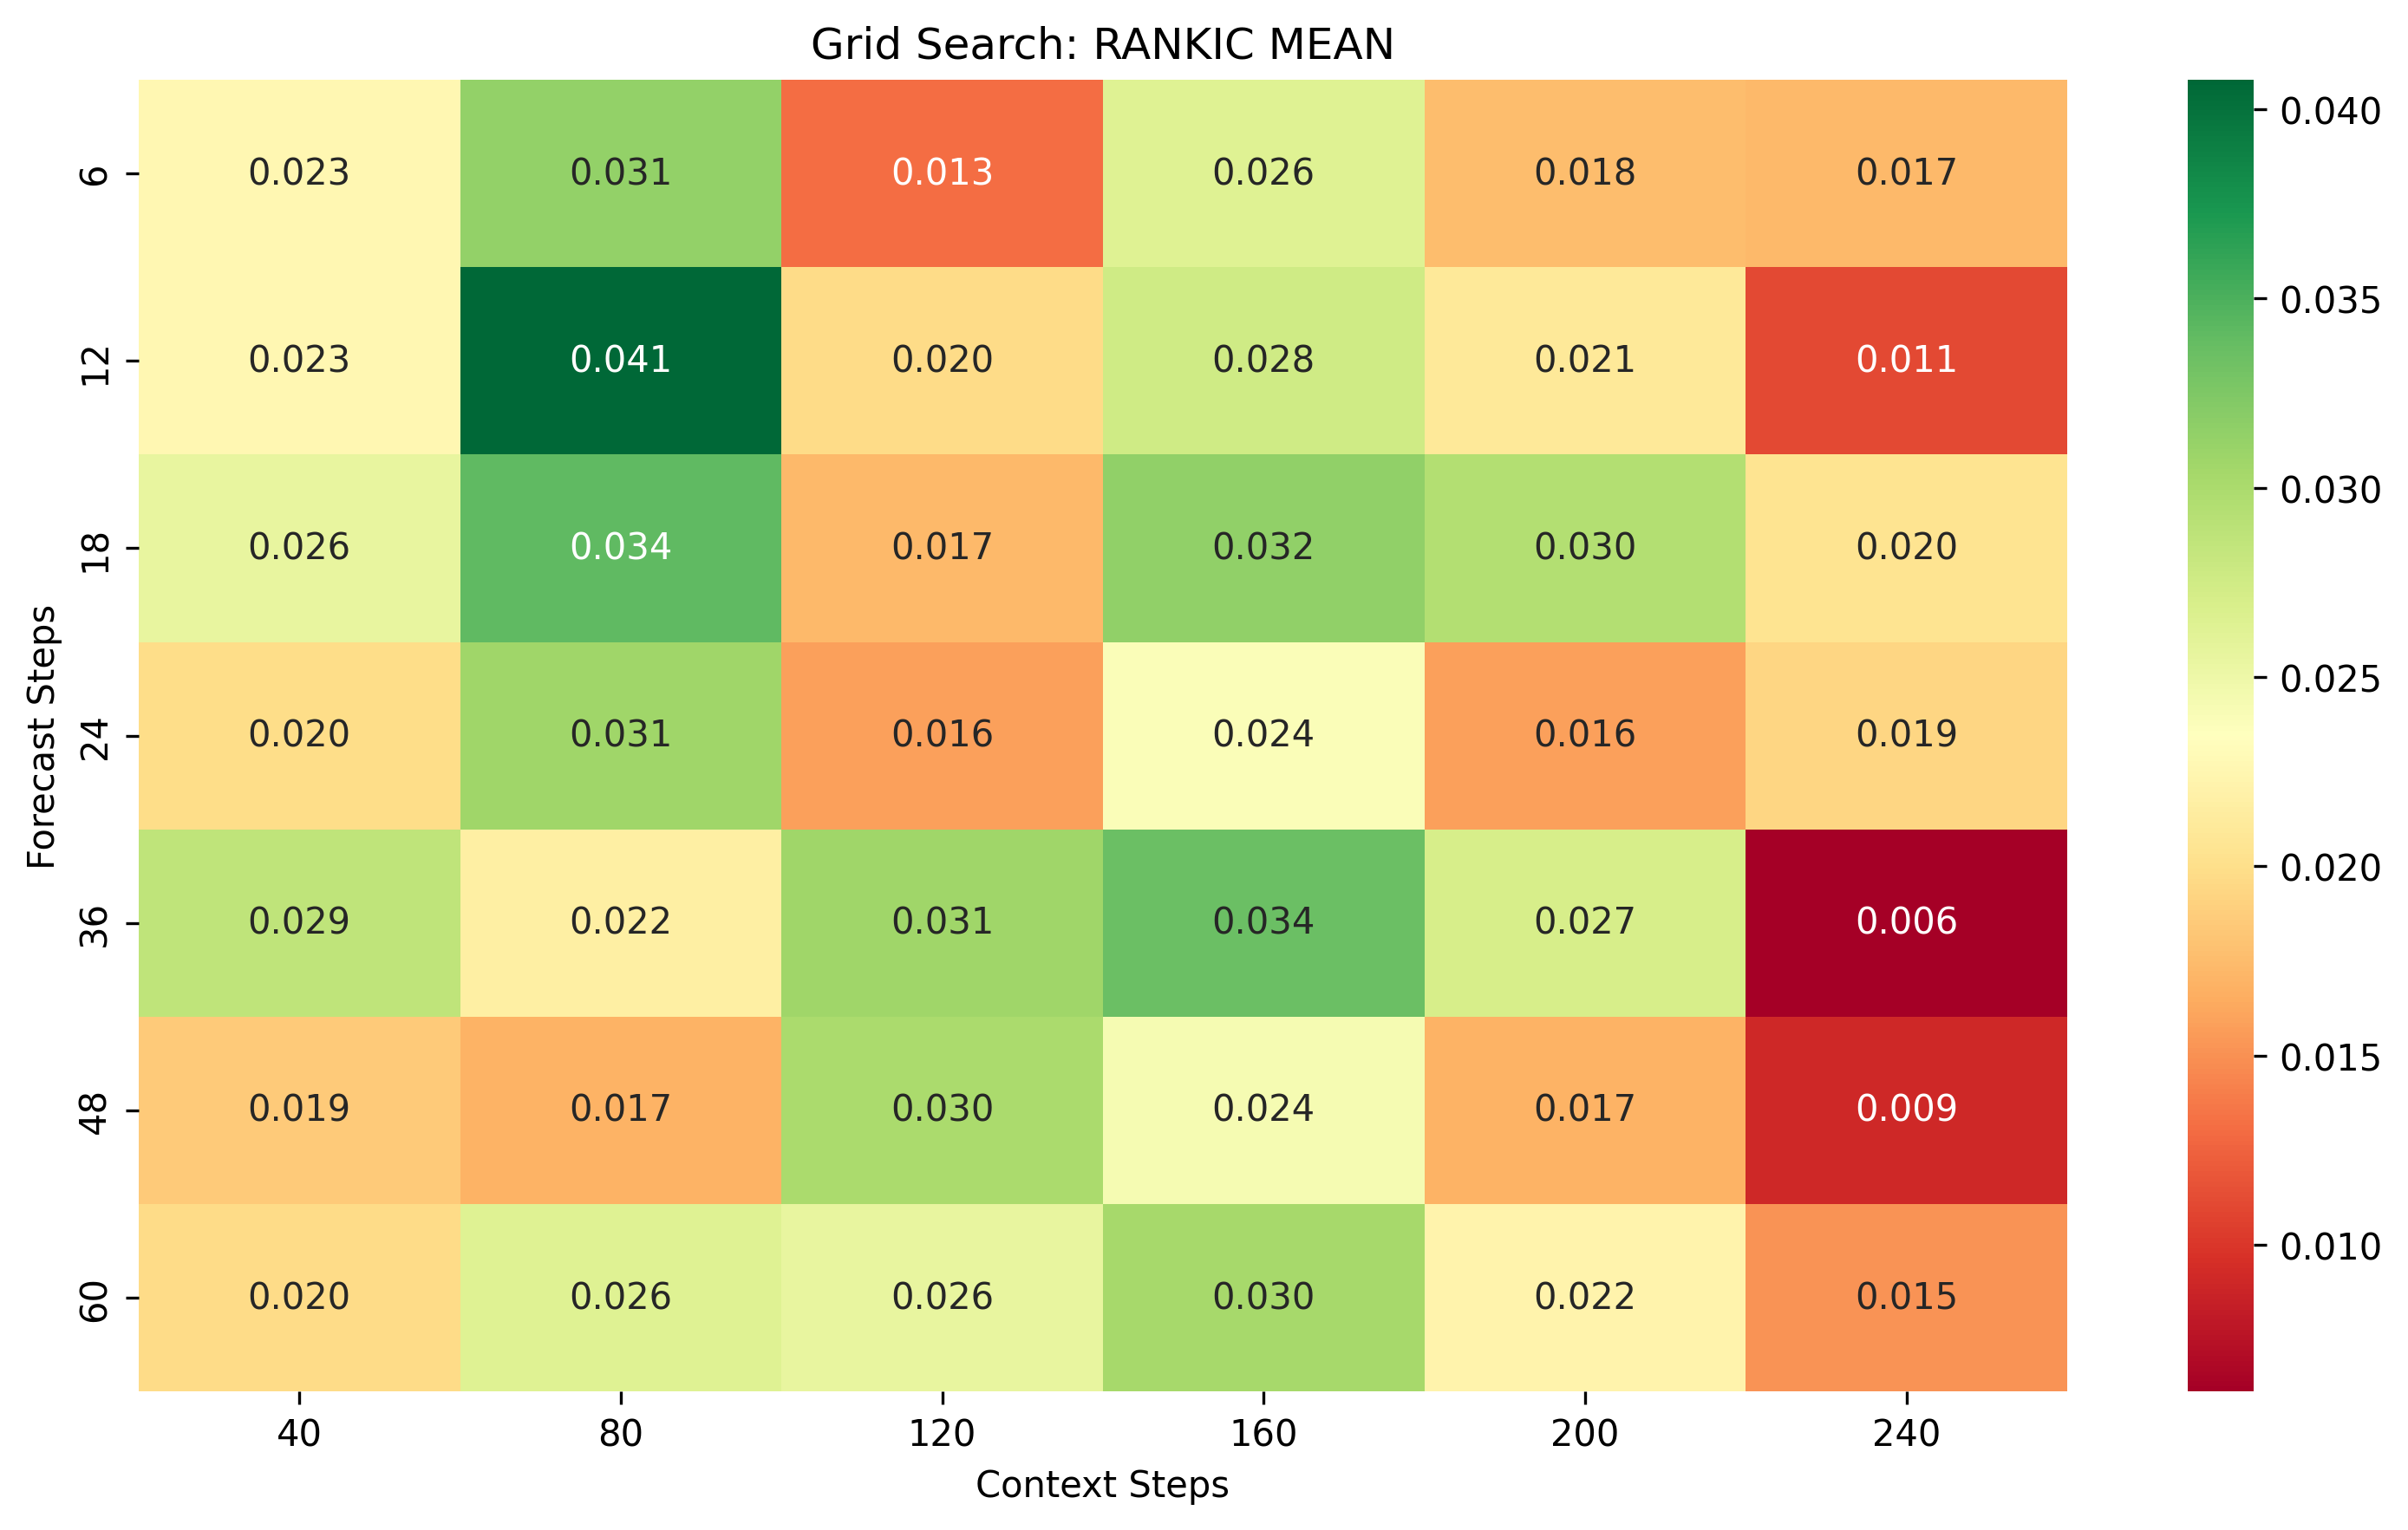


ANALYSIS COMPLETE
Results directory: 03_sensitivity_analysis/data_parameters/results/raw_grid
Figures: 03_sensitivity_analysis/data_parameters/results/grid_results/
Summary: 03_sensitivity_analysis/data_parameters/results/grid_results/grid_search_summary.csv


In [7]:
import matplotlib.pyplot as plt
from IPython.display import Image, display
from pathlib import Path

if METHOD == 'sobol':
    fig_dir = Path("03_sensitivity_analysis/data_parameters/results/figures")
    
    print("Sobol Sensitivity Indices:")
    for metric in ['IC_Mean', 'RankIC_Mean', 'MAE_Mean']:
        img_path = fig_dir / f"sobol_{metric}.png"
        if img_path.exists():
            print(f"\n{metric}:")
            display(Image(filename=str(img_path)))
    
    print("\nParameter Response Curves:")
    for metric in ['IC_Mean', 'RankIC_Mean', 'MAE_Mean']:
        img_path = fig_dir / f"response_{metric}.png"
        if img_path.exists():
            print(f"\n{metric}:")
            display(Image(filename=str(img_path)))

elif METHOD == 'grid':
    fig_dir = Path("03_sensitivity_analysis/data_parameters/results/")
    
    print("Grid Search Heatmaps:")
    for metric in ['mae_mean', 'ic_mean', 'rankic_mean']:
        img_path = fig_dir / f"heatmap_{metric}.png"
        if img_path.exists():
            print(f"\n{metric.upper()}:")
            display(Image(filename=str(img_path)))

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"Results directory: {RESULTS_DIR}")
if METHOD == 'sobol':
    print("Figures: 03_sensitivity_analysis/data_parameters/results/figures/")
    print("Report: 03_sensitivity_analysis/data_parameters/results/sensitivity_report.txt")
elif METHOD == 'grid':
    print("Figures: 03_sensitivity_analysis/data_parameters/results/grid_results/")
    print("Summary: 03_sensitivity_analysis/data_parameters/results/grid_results/grid_search_summary.csv")